In [11]:
# 1. Import Libraries

import tensorflow as tf
import matplotlib.pyplot as plt
import zipfile
import os

from google.colab import files
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models


In [12]:
# 2. Upload Dataset

uploaded = files.upload()

Saving archive (10).zip to archive (10).zip


In [13]:
# get uploaded file name
zip_file = list(uploaded.keys())[0]


In [14]:
# 3. Unzip Dataset

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall()

print("Dataset Extracted")

# show folders
print("Folders:", os.listdir())

Dataset Extracted
Folders: ['.config', 'archive (10).zip', 'no', 'brain_tumor_dataset', 'yes', 'sample_data']


In [15]:
# 4. Dataset Folder

dataset_path = "brain_tumor_dataset"

In [16]:
# 5. Image Parameters

img_size = 224
batch_size = 32

In [17]:
# 6. Data Preprocessing

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

val_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)


Found 203 images belonging to 2 classes.
Found 50 images belonging to 2 classes.


In [18]:
# 7. CNN Model

model = models.Sequential([

    layers.Input(shape=(224,224,3)),

    layers.Conv2D(32,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(1,activation='sigmoid')
])


In [19]:
# 8. Compile Model

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# 9. Train Model

history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)


Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.5961 - loss: 0.6808 - val_accuracy: 0.7600 - val_loss: 0.5389
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.7635 - loss: 0.5116 - val_accuracy: 0.7600 - val_loss: 0.5329
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.8424 - loss: 0.4335 - val_accuracy: 0.7600 - val_loss: 0.5716
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.8424 - loss: 0.3794 - val_accuracy: 0.7800 - val_loss: 0.5565
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.8473 - loss: 0.4047 - val_accuracy: 0.7800 - val_loss: 0.5551
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.8621 - loss: 0.3494 - val_accuracy: 0.7400 - val_loss: 0.5140
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.8670 - loss: 0.2971 - val_accuracy: 0.7800 - val_loss: 0.4614
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.9310 - loss: 0.1958 - val_accuracy: 0.8200 - val_loss: 0.4687
Epoch 9/

In [21]:
# 10. Evaluate Model

loss, accuracy = model.evaluate(val_generator)

print("Validation Accuracy:", accuracy)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 308ms/step - accuracy: 0.8800 - loss: 0.5762
Validation Accuracy: 0.8799999952316284


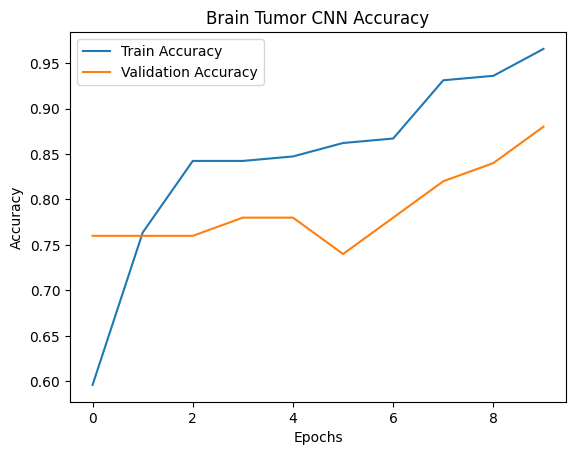

In [22]:
# 11. Plot Accuracy

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Brain Tumor CNN Accuracy")
plt.show()